In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [12]:
df = pd.read_csv('data/sra_master_metadata.csv')

In [13]:
pd.set_option('display.max_columns', None)

In [14]:
df.head(1)

,study_accession,study_title,experiment_accession,experiment_title,experiment_desc,organism_taxid,organism_name,library_name,library_strategy,library_source,library_selection,library_layout,sample_accession,sample_title,biosample,bioproject,instrument,instrument_model,instrument_model_desc,total_spots,total_size,run_accession,run_total_spots,run_total_bases
0,ERP000111,Epidemiology of tuberculosis,ERX2006544,Illumina Genome Analyzer II paired end sequencing,Illumina Genome Analyzer II paired end sequencing,1773,Mycobacterium tuberculosis,NT220447P,WGS,GENOMIC,RANDOM,PAIRED,ERS016364,NaN,SAMEA968159,PRJEB2057,Illumina Genome Analyzer II,Illumina Genome Analyzer II,ILLUMINA,4247069,415847358,ERR029203,4247069.0,679531040.0


In [15]:
print(f"shape of data is: {df.shape}"), print()
print(df.info())

shape of data is: (20485, 24)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20485 entries, 0 to 20484
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_accession        20485 non-null  object 
 1   study_title            20485 non-null  object 
 2   experiment_accession   20485 non-null  object 
 3   experiment_title       20185 non-null  object 
 4   experiment_desc        20485 non-null  object 
 5   organism_taxid         20485 non-null  int64  
 6   organism_name          20485 non-null  object 
 7   library_name           18575 non-null  object 
 8   library_strategy       20485 non-null  object 
 9   library_source         20485 non-null  object 
 10  library_selection      20485 non-null  object 
 11  library_layout         20485 non-null  object 
 12  sample_accession       20485 non-null  object 
 13  sample_title           0 non-null      float64
 14  biosample              

In [17]:
MTB_GENOME_SIZE = 4_411_532 

df['estimated_coverage'] = (df['run_total_bases'] / MTB_GENOME_SIZE).round(2)
df['size_mb']            = (df['total_size'] / 1e6).round(2)
df['run_prefix']         = df['run_accession'].str[:3]

print(f"Columns: {df.columns.tolist()}"), print()
df.head(3)

Columns: ['study_accession', 'study_title', 'experiment_accession', 'experiment_title', 'experiment_desc', 'organism_taxid', 'organism_name', 'library_name', 'library_strategy', 'library_source', 'library_selection', 'library_layout', 'sample_accession', 'sample_title', 'biosample', 'bioproject', 'instrument', 'instrument_model', 'instrument_model_desc', 'total_spots', 'total_size', 'run_accession', 'run_total_spots', 'run_total_bases', 'estimated_coverage', 'size_mb', 'run_prefix']



,study_accession,study_title,experiment_accession,experiment_title,experiment_desc,organism_taxid,organism_name,library_name,library_strategy,library_source,library_selection,library_layout,sample_accession,sample_title,biosample,bioproject,instrument,instrument_model,instrument_model_desc,total_spots,total_size,run_accession,run_total_spots,run_total_bases,estimated_coverage,size_mb,run_prefix
0,ERP000111,Epidemiology of tuberculosis,ERX2006544,Illumina Genome Analyzer II paired end sequencing,Illumina Genome Analyzer II paired end sequencing,1773,Mycobacterium tuberculosis,NT220447P,WGS,GENOMIC,RANDOM,PAIRED,ERS016364,NaN,SAMEA968159,PRJEB2057,Illumina Genome Analyzer II,Illumina Genome Analyzer II,ILLUMINA,4247069,415847358,ERR029203,4247069.0,679531040.0,154.04,415.85,ERR
1,ERP140407,BDQ and CFZ resistant mutants of Mycobacterium...,ERX14192510,Illumina MiSeq paired end sequencing,Illumina MiSeq paired end sequencing,1773,Mycobacterium tuberculosis,ATCC-BD4-0,WGS,GENOMIC,RANDOM PCR,PAIRED,ERS23863174,NaN,SAMEA117873221,PRJEB55505,Illumina MiSeq,Illumina MiSeq,ILLUMINA,439391,152010531,ERR14788652,439391.0,250883540.0,56.87,152.01,ERR
2,ERP140407,BDQ and CFZ resistant mutants of Mycobacterium...,ERX14192511,Illumina MiSeq paired end sequencing,Illumina MiSeq paired end sequencing,1773,Mycobacterium tuberculosis,ATCC-CFZ-16X,WGS,GENOMIC,RANDOM PCR,PAIRED,ERS23863175,NaN,SAMEA117873222,PRJEB55505,Illumina MiSeq,Illumina MiSeq,ILLUMINA,375444,130782688,ERR14788653,375444.0,214053092.0,48.52,130.78,ERR


<h2 style="color:#39FF14; border-bottom: 2px solid #5D6D7E; padding-bottom: 8px;">
    Data quality check 
</h2>

In [21]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
qc = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
qc = qc[qc['missing_count'] > 0].sort_values('missing_%', ascending=False)

In [22]:
print("columns with missing values")
display(qc)

columns with missing values


,missing_count,missing_%
sample_title,20485,100.00
library_name,1910,9.32
experiment_title,300,1.46
run_total_spots,5,0.02
run_total_bases,5,0.02
estimated_coverage,5,0.02


In [20]:
print(f"Total rows       : {len(df):,}")
print(f"Duplicate run IDs: {df['run_accession'].duplicated().sum():,}")
print(f"Unique run IDs   : {df['run_accession'].nunique():,}")
print(f"Unique samples   : {df['sample_accession'].nunique():,}")
print(f"Unique studies   : {df['study_accession'].nunique():,}")
print(f"Unique bioprojects: {df['bioproject'].nunique():,}")
print(f"Unique organisms : {df['organism_name'].nunique():,}")

Total rows       : 20,485
Duplicate run IDs: 890
Unique run IDs   : 19,595
Unique samples   : 17,283
Unique studies   : 751
Unique bioprojects: 751
Unique organisms : 637


<h2 style="color:#39FF14; border-bottom: 2px solid #5D6D7E; padding-bottom: 8px;">
    Taxanomy dist.
</h2>

In [37]:
org_counts = df['organism_name'].value_counts()
print(org_counts)

organism_name
Mycobacterium tuberculosis                        17388
Mycobacterium tuberculosis H37Rv                     86
Mycobacterium tuberculosis variant bovis             13
Mycobacterium tuberculosis TB_RSA154                  8
Mycobacterium tuberculosis TB_RSA25                   8
                                                  ...  
Mycobacterium tuberculosis TKK_02_0080                2
Mycobacterium tuberculosis TKK_02_0031                2
Mycobacterium tuberculosis UT0028                     2
Mycobacterium tuberculosis subsp. tuberculosis        2
Mycobacterium tuberculosis variant africanum          1
Name: count, Length: 637, dtype: int64


In [36]:
top_orgs = org_counts.head(5)
other_count = org_counts.iloc[5:].sum()
plot_data = pd.concat([top_orgs, pd.Series({'Mtb (other strains)': other_count})])

print(f"top organisms: \n{top_orgs}"), print()
print(f"other organisms: {other_count}")

print(), print(f"plot data: \n{plot_data}")

top organisms: 
organism_name
Mycobacterium tuberculosis                  17388
Mycobacterium tuberculosis H37Rv               86
Mycobacterium tuberculosis variant bovis       13
Mycobacterium tuberculosis TB_RSA154            8
Mycobacterium tuberculosis TB_RSA25             8
Name: count, dtype: int64

other organisms: 2982

plot data: 
Mycobacterium tuberculosis                  17388
Mycobacterium tuberculosis H37Rv               86
Mycobacterium tuberculosis variant bovis       13
Mycobacterium tuberculosis TB_RSA154            8
Mycobacterium tuberculosis TB_RSA25             8
Mtb (other strains)                          2982
dtype: int64


(None, None)

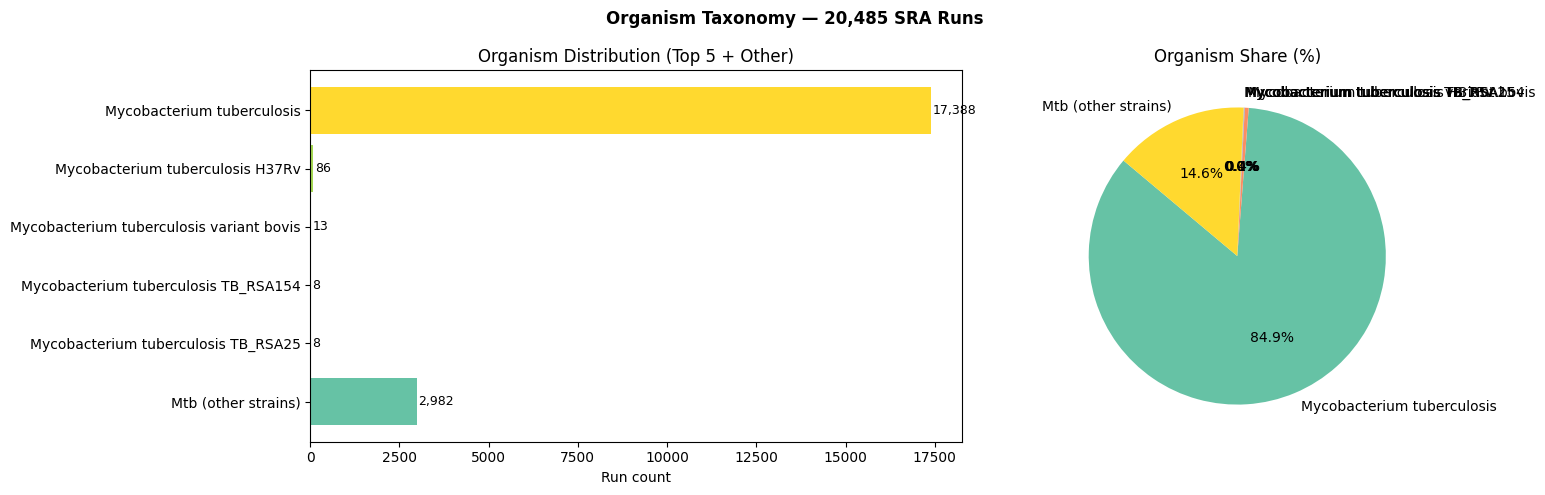

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].barh(plot_data.index[::-1], plot_data.values[::-1], color=sns.color_palette("Set2", len(plot_data)))
axes[0].set_xlabel('Run count')
axes[0].set_title('Organism Distribution')
for i, v in enumerate(plot_data.values[::-1]):
    axes[0].text(v + 50, i, f'{v:,}', va='center', fontsize=9)


axes[1].pie(plot_data.values, labels=plot_data.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Set2", len(plot_data)))
axes[1].set_title('Organism Share (%)')

plt.suptitle('Organism Taxonomy — 20,485 SRA Runs', fontweight='bold')
plt.tight_layout()
plt.show()

<h2 style="color:#39FF14; border-bottom: 2px solid #5D6D7E; padding-bottom: 8px;">
    Sequencing instruement and platform analysis

</h2>

In [62]:
inst_counts = df['instrument_model'].value_counts()
print("Full instrument breakdown:")
display(inst_counts.reset_index().rename(columns={'instrument_model':'instrument','count':'n_runs'}))

Full instrument breakdown:


,instrument,n_runs
0,Illumina HiSeq 2000,8005
1,NextSeq 500,3532
2,Illumina MiSeq,2678
3,Illumina HiSeq 2500,2143
4,NextSeq 550,1367
5,NextSeq 2000,866
6,Illumina NovaSeq 6000,409
7,Element AVITI,302
8,MinION,273
9,Illumina HiSeq 3000,241


In [61]:
plat_counts = df['instrument_model_desc'].value_counts()
print("Platform family:")
display(plat_counts.reset_index().rename(columns={'instrument_model_desc':'platform','count':'n_runs'}))

Platform family:


,platform,n_runs
0,ILLUMINA,19779
1,ELEMENT,302
2,OXFORD_NANOPORE,273
3,PACBIO_SMRT,127
4,DNBSEQ,4


In [59]:
long_read = df['instrument_model_desc'].isin(['OXFORD_NANOPORE','PACBIO_SMRT','ELEMENT'])
print(f"\nShort-read (Illumina + DNBSEQ) : {(~long_read).sum():,}")
print(f"Long-read / other platform      : {long_read.sum():,}")


Short-read (Illumina + DNBSEQ) : 19,783
Long-read / other platform      : 702


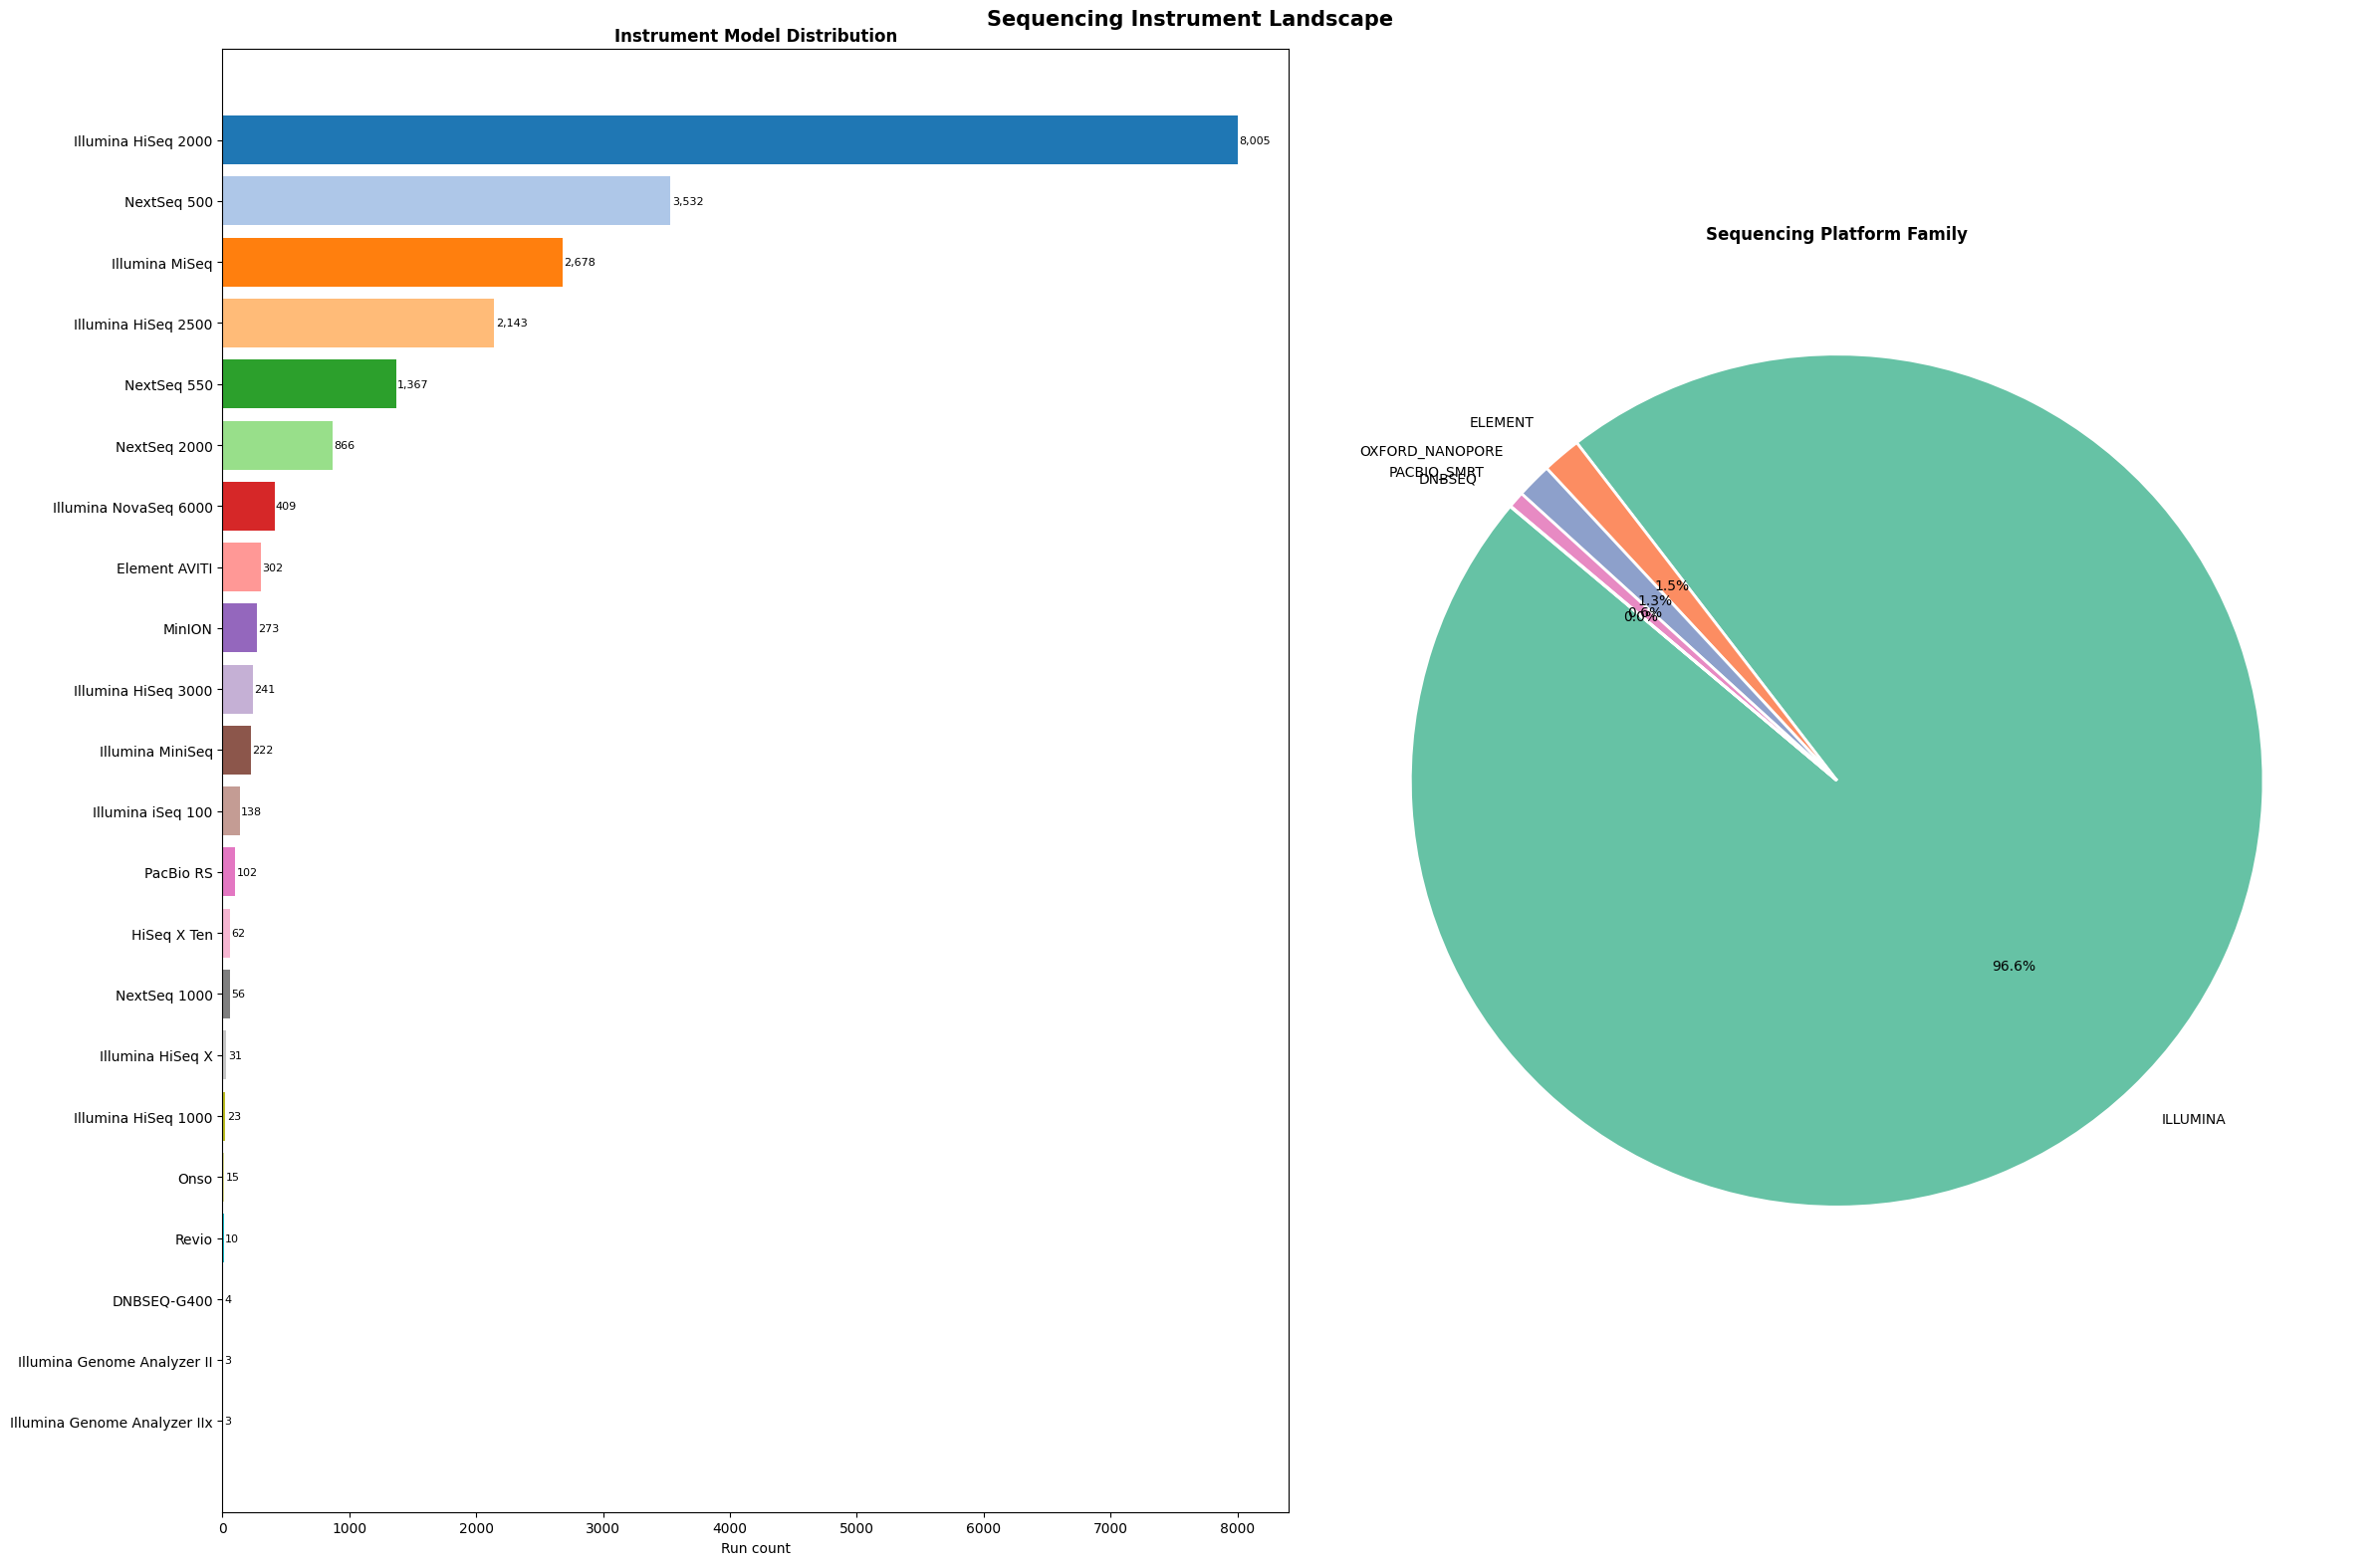

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(24,16))
axes[0].barh(inst_counts.index[::-1], inst_counts.values[::-1], color=sns.color_palette("tab20", len(inst_counts))[::-1])
axes[0].set_xlabel('Run count')
axes[0].set_title('Instrument Model Distribution', fontweight='bold')
for i, v in enumerate(inst_counts.values[::-1]):
    axes[0].text(v+10, i, f'{v:,}', va='center', fontsize=8)

axes[1].pie(plat_counts.values, labels=plat_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Set2", len(plat_counts)), wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Sequencing Platform Family', fontweight='bold')

plt.suptitle('Sequencing Instrument Landscape', fontweight='bold', fontsize=15)
plt.tight_layout()
plt.show()

<h2 style="color:#39FF14; border-bottom: 2px solid #5D6D7E; padding-bottom: 8px;">
    Sequencing depth and coverage
</h2>

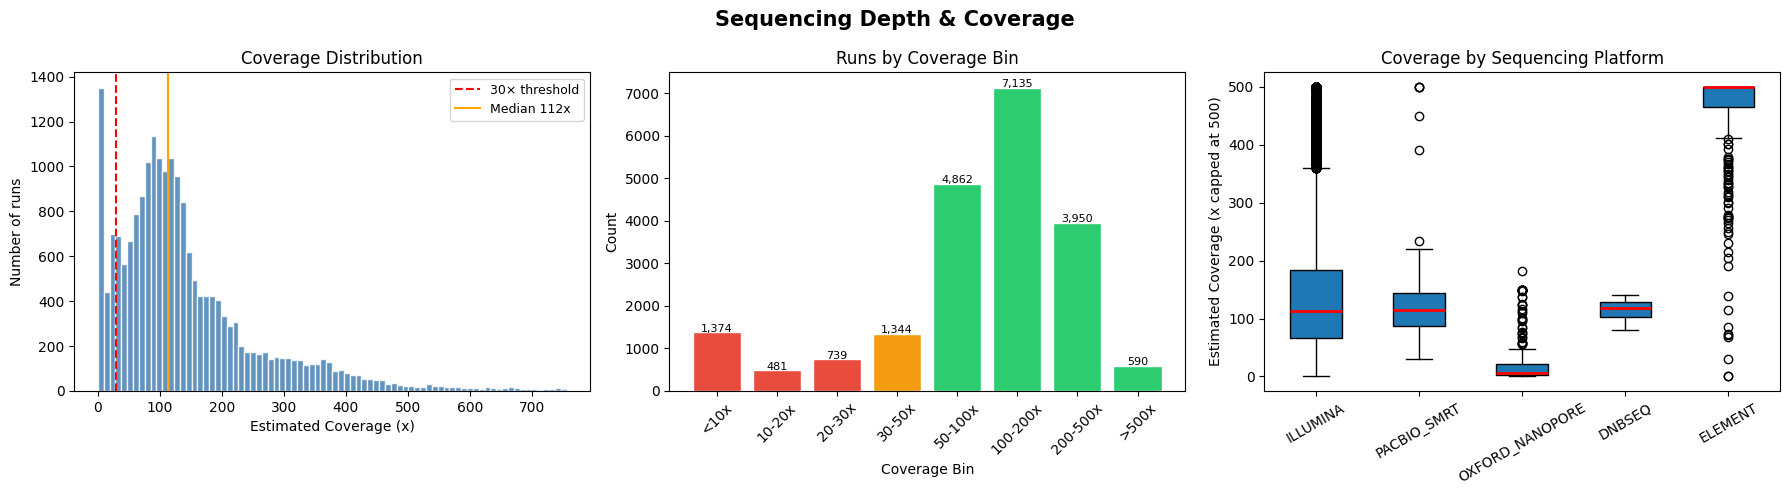

=== Coverage Summary ===
count    20480.00
mean       157.63
std        228.17
min          0.00
25%         65.24
50%        113.34
75%        186.58
max       8552.99
Name: estimated_coverage, dtype: float64

Runs with ≥30x coverage  : 87.3%
Runs with ≥100x coverage : 57.0%
\nCoverage bins:


,bin,n_runs
0,<10x,1374
1,10-20x,481
2,20-30x,739
3,30-50x,1344
4,50-100x,4862
5,100-200x,7135
6,200-500x,3950
7,>500x,590


In [64]:
cov = df['estimated_coverage'].dropna()
cov = cov[cov < cov.quantile(0.99)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(cov, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(30, color='red', linestyle='--', linewidth=1.5, label='30× threshold')
axes[0].axvline(cov.median(), color='orange', linestyle='-', linewidth=1.5, label=f'Median {cov.median():.0f}x')
axes[0].set_xlabel('Estimated Coverage (x)')
axes[0].set_ylabel('Number of runs')
axes[0].set_title('Coverage Distribution')
axes[0].legend(fontsize=9)

bins   = [0, 10, 20, 30, 50, 100, 200, 500, float('inf')]
labels = ['<10x','10-20x','20-30x','30-50x','50-100x','100-200x','200-500x','>500x']
df['cov_bin'] = pd.cut(df['estimated_coverage'], bins=bins, labels=labels)
bin_counts = df['cov_bin'].value_counts().reindex(labels)

colors = ['#e74c3c' if l in ['<10x','10-20x','20-30x'] else '#f39c12' if l == '30-50x' else '#2ecc71' for l in labels]
axes[1].bar(labels, bin_counts.values, color=colors, edgecolor='white')
axes[1].set_xlabel('Coverage Bin')
axes[1].set_ylabel('Count')
axes[1].set_title('Runs by Coverage Bin')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(bin_counts.values):
    axes[1].text(i, v+20, f'{v:,}', ha='center', fontsize=8)

box_data = [df[df['instrument_model_desc']==p]['estimated_coverage'].dropna().clip(0,500).values for p in df['instrument_model_desc'].unique()]
axes[2].boxplot(box_data, labels=df['instrument_model_desc'].unique(), patch_artist=True, medianprops=dict(color='red',linewidth=2))
axes[2].set_ylabel('Estimated Coverage (x capped at 500)')
axes[2].set_title('Coverage by Sequencing Platform')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Sequencing Depth & Coverage', fontweight='bold', fontsize=15)
plt.tight_layout()
plt.savefig('fig_05_coverage.png', bbox_inches='tight')
plt.show()

print("=== Coverage Summary ===")
print(df['estimated_coverage'].describe().round(2))

pct_above_30 = (df['estimated_coverage'] >= 30).mean() * 100
pct_above_100 = (df['estimated_coverage'] >= 100).mean() * 100
print(f"\nRuns with ≥30x coverage  : {pct_above_30:.1f}%")
print(f"Runs with ≥100x coverage : {pct_above_100:.1f}%")

print("\\nCoverage bins:")
display(bin_counts.reset_index().rename(columns={'cov_bin':'bin','count':'n_runs'}))